# Neural network potentials for Lennard-Jones clusters

- **Project: Neural network potentials for Lennard-Jones clusters**: We develop a neural network (NN) potential for small Lennard-Jones (LJ) clusters. There will be three steps that will be worked on :
    - setting up the LJ clusters and creating several datasets
        - Initial cluster setup
        - Optimising cluster setup
        - Creating datasets using Monte Carlo sampling
            - MC sampling and dataset for 3D LJ cluster
            - MC sampling and dataset for 2D LJ cluster
        
    - optimizing the hyper-parameters and training the NN
        - Network architecture and weight optimization
        - Learning curve with respect to dataset size
        
    - application, transferability, and limitations
        - Use the fitted NN to perform Monte Carlo (MC) sampling of the 3D clusters
        - Transferability of the NN potential 
            - Low and high temperature data
            - Fitting with mixed datasets or including all datasets
            - Transferability from 3D to 2D

## Part 1: setting up the LJ clusters and creating several datasets

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, exp

from ase import Atoms, units
from ase.calculators.lj import LennardJones
from ase.optimize import BFGS
from ase.constraints import FixedPlane
from ase.visualize import view

## Initial cluster setup

To setup the cluster structures and evaluate the LJ potential, we use the ‘Atomic Simulation Environment’ (ASE, https://wiki.fysik.dtu.dk/ase/), a set of Python tools for atomistic simulations.

We create atom objects for 2 cluster. Both clusters consist of 7 atoms.  
**For the 2D cluster**, we place the central atom at the origin and the other 6 atoms on the vertices of a hexagon around the central atom in the xy-plane.  
**For the 3D cluster**, we place the central atom again at the origin and the other 6 atoms on the vertices of an octahedron. We set the initial distance between the central atom and its 6 neighbours to 1.1 Angstrom.  

**LJ potential**

$$
V_{\text{LJ}}(\mathbf{r}) = \sum_i^N \sum_{j>i}^N 4 \epsilon_{ij} \left[ \left(\frac{\sigma_{ij}}{|\mathbf{r}_{ij}|} \right)^{12} - \left(\frac{\sigma_{ij}}{|\mathbf{r}_{ij}|} \right)^{6} \right]
$$

$\sigma$ determines the length scale of the interaction (size of the particles) and $\epsilon$ the interaction strength (depth of the potential).  The default values in ASE are $\sigma = 1$ Ang and $\epsilon = 1$ eV.

In [16]:
# set up 2 clusters with 7 atoms each, one 3d, one 2d

d = 1.1

# 3d cluster
clus3d = Atoms('7Ar',[(0.0,0.0,0.0),(d/sqrt(2),d/sqrt(2),0.0),(-d/sqrt(2),d/sqrt(2),0.0),
                      (d/sqrt(2),-d/sqrt(2),0.0),(-d/sqrt(2),-d/sqrt(2),0.0),(0,0,d),(0,0,-d)])
print('\n3D cluster initial positions:')
print(clus3d.get_positions())

# 2d cluster
print('\n2D cluster initial positions:')
clus2d = Atoms('7Ar',[(0.0,0.0,0.0),(d,0.0,0.0),(-d,0.0,0.0),(d/2,d/2*sqrt(3),0.0),
                     (-d/2,d/2*sqrt(3),0.0),(-d/2,-d/2*sqrt(3),0.0),(d/2,-d/2*sqrt(3),0)])
print(clus2d.get_positions())

# set LJ calculator and print out initial energy
ljcalc = LennardJones()
clus3d.calc = ljcalc
clus2d.calc = ljcalc

clus3dpot = clus3d.get_potential_energy()
clus2dpot = clus2d.get_potential_energy()

print('\n')
print(f'3D cluster initial potential energy = {clus3dpot:5.3f} eV')
print(f'2D cluster initial potential energy = {clus2dpot:5.3f} eV')
print('\n')


3D cluster initial positions:
[[ 0.          0.          0.        ]
 [ 0.77781746  0.77781746  0.        ]
 [-0.77781746  0.77781746  0.        ]
 [ 0.77781746 -0.77781746  0.        ]
 [-0.77781746 -0.77781746  0.        ]
 [ 0.          0.          1.1       ]
 [ 0.          0.         -1.1       ]]

2D cluster initial positions:
[[ 0.          0.          0.        ]
 [ 1.1         0.          0.        ]
 [-1.1         0.          0.        ]
 [ 0.55        0.95262794  0.        ]
 [-0.55        0.95262794  0.        ]
 [-0.55       -0.95262794  0.        ]
 [ 0.55       -0.95262794  0.        ]]


3D cluster initial potential energy = -9.038 eV
2D cluster initial potential energy = -12.282 eV




### Optimizing the initial cluster structures
To optimise the initial positions of the atoms in the two clusters by minimising the forces, we use the **BFGS minimizer** in ASE (https://wiki.fysik.dtu.dk/ase/ase/optimize.html? highlight=bfgs#ase.optimize.BFGS) and perform an energy minimization with a maximum force of 0.05.

- For 2D cluster, to apply constraints to the xy-plane, we use ase.FixedPlane constraint in ASE
- Visualize the clusters: using ase.visualize.view
- to calculate Pairwise distances : get_all_distances() of cluster object in ase

In [19]:
# perform initial energy minimizaion
dyn3d = BFGS(clus3d)
dyn3d.run(fmax=0.05)

# constrain 2D cluster to xy-plane
c=[]
for i in range(len(clus2d)):
    c.append(FixedPlane(indices=i, direction=[0,0,1]))
clus2d.set_constraint(c)
dyn2d = BFGS(clus2d)
dyn2d.run(fmax=0.05)


# print positions and energy after relaxation
print('\n3D cluster positions after relaxation:')
print(clus3d.get_positions())
clus3dpot = clus3d.get_potential_energy()
print(f'\n3D cluster potential energy after relaxation = {clus3dpot:5.3f} eV')

print('\n2D cluster positions after relaxation:')
print(clus2d.get_positions())
clus2dpot = clus2d.get_potential_energy()
print(f'\n2D cluster potential energy after relaxation = {clus2dpot:5.3f} eV')

# reset all z-values of 2D cluster to zero and plot positions and energy again
# pos2d = clus2d.get_positions()
# for apos in pos2d:
#     apos[2] = 0.0
    
# clus2d.set_positions(pos2d)
# print('\n2D cluster positions after relaxation and reset:')
# print(clus2d.get_positions())
# clus2dpot = clus2d.get_potential_energy()
# print(f'\n2D cluster potential energy after relaxation and reset = {clus2dpot:5.3f} eV')

      Step     Time          Energy          fmax
BFGS:    0 11:55:47       -9.037942        1.150877
BFGS:    1 11:55:47       -9.087128        0.227981
BFGS:    2 11:55:47       -9.088710        0.031700
      Step     Time          Energy          fmax
BFGS:    0 11:55:47      -12.281571        2.644603
BFGS:    1 11:55:47      -12.300262        1.941579
BFGS:    2 11:55:47      -12.415891        0.387616
BFGS:    3 11:55:47      -12.419639        0.080334
BFGS:    4 11:55:47      -12.419798        0.002519

3D cluster positions after relaxation:
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 7.68114033e-01  7.68114033e-01 -1.63654088e-19]
 [-7.68114033e-01  7.68114033e-01 -2.18163371e-19]
 [ 7.68114033e-01 -7.68114033e-01  1.35413075e-20]
 [-7.68114033e-01 -7.68114033e-01 -1.77008740e-21]
 [ 2.39023931e-20 -2.54992116e-20  1.08627728e+00]
 [ 0.00000000e+00  0.00000000e+00 -1.08627728e+00]]

3D cluster potential energy after relaxation = -9.089 eV

2D cluster positions after 

In [20]:
view(clus2d, viewer='x3d')

In [21]:
#view(clus3d)
view(clus3d, viewer='x3d')

## Pairwise distances

In [22]:
# make a list of all distances
dist3d = clus3d.get_all_distances()
#print(dist3d)

# sort list
dist3d = np.sort(np.ravel(dist3d))
#print(dist3d)

# remove 0
dist3d = np.trim_zeros(dist3d)
#print(dist3d)

# only every second entry (double counting of bonds)
dist3d = dist3d[::2]
print(dist3d)

#length should be N*(N-1)/2 -> for N=7 there are 21; this will be the input vector to the NN!
print(len(dist3d))
print('\n')

#now the same for the 2D cluster
dist2d = np.trim_zeros(np.sort(np.ravel(clus2d.get_all_distances())))
dist2d = dist2d[::2]
print(dist2d)
print(len(dist2d))

# save original configurations
clus3d_orig_pos = clus3d.get_positions()
clus2d_orig_pos = clus2d.get_positions()


[1.08627728 1.08627728 1.08627728 1.08627728 1.08627728 1.08627728
 1.53622807 1.53622807 1.53622807 1.53622807 1.53622807 1.53622807
 1.53622807 1.53622807 1.53622807 1.53622807 1.53622807 1.53622807
 2.17255457 2.17255457 2.17255457]
21


[1.11848102 1.11848102 1.11848102 1.11848102 1.11848102 1.11848102
 1.11848102 1.11848102 1.11848102 1.11848102 1.11848102 1.11848102
 1.93726595 1.93726595 1.93726595 1.93726595 1.93726595 1.93726595
 2.23696204 2.23696204 2.23696204]
21


## Creating datasets using Monte Carlo sampling

To train the NN, a number of different configurations of the clusters is required to sample the potential energy surface of the clusters. 
We will use Monte Carlo (MC) sampling at different temperatures to create a set of meaningful configurations, that is configurations that have a significant contribution to the partition function in the canonical ensemble.   

An MC step consists of two parts: 
- propose a trial configuration. 
- accept/reject the trial configuration based on the detailed balance criterion. If the trial configuration is rejected, the old configuration is recounted in the ensemble.  

How to create a trial configuration?  
To create trial configuration r<sup>(n)</sup> from the old one r<sup>(o)</sup>, a displacement is added to all atoms in the cluster
$$r_i^{(n)} = r_i^{(o)} + \Delta r \tag{Eq. 1}$$

where the displacements $\Delta r$ are Gaussian distributed random number with 0 mean and a standard deviation $\sigma_G$ (width of the Gaussian, controls the magnitude of the displacement). The acceptance probability for the trial configuration is
$$p_{acc} (o \rightarrow n) = min\left(1, exp(-\beta \left(E_{pot}^{n} - E_{pot}^{o})\right)\right) \tag{Eq. 2}$$
with $\beta = 1/(k_BT)$

An MC step thus includes the following:
1. compute energy of old configuration and save old positions
2. create new configuration by adding a random displacement to all atoms according to Eq. (1)
3. compute energy of new configuration
4. accept/reject new configuration according to Eq. 2






### MC sampling function

In [23]:
import ase

def mcstep(config: ase.Atoms, T: float, sigma: float, D: int, rng: np.random.Generator):
    """Metropolis-Hastings algorithm to sample atomic configurations at constant temperature using global random displacement moves from a Gaussian distribution.

    Parameters
    ----------
    config:
        an atomic configuration.
    T:
        temperature of the system
    sigma:
        magnitude of the random displacement
    D:
        dimensionality of the system (either 2 or 3)
    rng:
        a random generator from numpy.random
    
    Return
    ------

    config: ase.Atoms
        the modified configuration
    accetance: int
        whether the move has been accepted
    """
    
    e_old = config.get_potential_energy()
    pos_old = config.get_positions()
    pos_new = config.get_positions()
    # sample random displacements
    displacements = rng.normal(loc=0.0, scale=sigma, size=pos_new.shape)
    pos_new += displacements
    if D == 2:
        # set the z dimension back to 0
        pos_new[:, 2] = 0

    config.set_positions(pos_new)
    e_new = config.get_potential_energy()
    
    # here's the MC acceptance
    dE = e_new - e_old
    if rng.uniform() < exp(-dE/(units.kB*T)):
        config.set_positions(pos_new)
        return config, 1
    else:
        config.set_positions(pos_old)
        return config, 0   

### MC sampling and dataset for 3D LJ cluster

The acceptance ratio is the ratio between accepted MC moves and the total number of MC steps, nacc/nMC. A good sampling is usually achieved if the acceptance ratio is around 0.4 − 0.5 and depends on the temperature and the displacement magnitude. For lower T, the displacement magnitude σG has to be chosen smaller to achieve a suitable acceptance ratio.

- With our initial optimized configuration of the 3D cluster, we run 20,000 MC steps at a temperature T = 10 K. We aim to find such value of $\sigma_G$ such that the acceptance ratio is around 0.5. _We collect configuration at every 20 MC steps, so that your dataset contains a total of 1000 data points_.
- Starting again with the initial optimized configuration, collect another dataset at T = 800 K by making sure to adjust $\sigma_G$. We run again 20 000 MC steps, print the energy every 500 steps and collect your data every 20 steps.

In [24]:
from numpy.random import default_rng
rng = default_rng(92458)

For 3D cluster with T = 10, sigma = 0.001 and 

In [ ]:
# start with original setup
clus3d.set_positions(clus3d_orig_pos)

# set dimensionality
D = 3

# displacement
# set temperature (in K)
T = 10
sigma = 0.001
# sigma = 0.01
# T = 800

# set number of MC steps
mcsteps = 20001

# how often to print energy
nprint = 500

# how often to collect data
ncollect = 20

# initialize acceptance counter
nacc = 0
X3d = []
y3d = []

# do a simple MC sampling to create a set of configurations
for i in range(mcsteps):
    
    clus3d, acc = mcstep(clus3d, T, sigma, D, rng)
    
    if acc:
        nacc += 1
    if (i % nprint) == 0:
        print(i,clus3d.get_potential_energy())
        
    if (i % ncollect) == 0:
        dist = clus3d.get_all_distances()
        dist = np.trim_zeros(np.sort(np.ravel(dist)))
        X3d.append(dist[::2])
        y3d.append(clus3d.get_potential_energy())
        
# print acceptances
#print(nacc)
print(f'\nAcceptance ratio: {float(nacc)/float(mcsteps):5.3f}')

X3d_10 = np.array(X3d)
y3d_10 = np.array(y3d)

# some setups:
# T = 800 K, sigma = 0.01
# T = 10 K, sigma = 0.001

0 -9.088362302690832


500 -9.104777712536748
1000 -9.308259948398403
1500 -9.888453346421894
2000 -10.782990325103889
2500 -11.84623539297285
3000 -12.711701132066509
3500 -13.329806084360419
4000 -13.578388806055088
4500 -13.701786249672494
5000 -13.886286148981757
5500 -14.352710837431799
6000 -14.819695547700258
6500 -14.950380204598407
7000 -15.257280276606176
7500 -15.409449659424208
8000 -15.471934016419764
8500 -15.472442219611349
9000 -15.470835837461486
9500 -15.469734446390458
10000 -15.471440407986258
10500 -15.473493334640063
11000 -15.472231000635189
11500 -15.469897700553382
12000 -15.470450271089808
12500 -15.472481813393653
13000 -15.472108876434786
13500 -15.475879356003121
14000 -15.472719712839288
14500 -15.471775163387267
15000 -15.472583740666572
15500 -15.468724102883105
16000 -15.468451633853714
16500 -15.472644535831462
17000 -15.472526059369429
17500 -15.472771310609197
18000 -15.473015716787868
18500 -15.471922498543055
19000 -15.464416839646832
19500 -15.472075529339897
20000 -15.

In [29]:
# start with original setup
clus3d.set_positions(clus3d_orig_pos)

# set dimensionality
D = 3

# displacement
# set temperature (in K)
sigma = 0.01
T = 800

# set number of MC steps
mcsteps = 20001

# how often to print energy
nprint = 500

# how often to collect data
ncollect = 20

# initialize acceptance counter
nacc = 0
X3d = []
y3d = []

# do a simple MC sampling to create a set of configurations
for i in range(mcsteps):
    
    clus3d, acc = mcstep(clus3d, T, sigma, D, rng)
    
    if acc:
        nacc += 1
    if (i % nprint) == 0:
        print(i,clus3d.get_potential_energy())
        
    if (i % ncollect) == 0:
        dist = clus3d.get_all_distances()
        dist = np.trim_zeros(np.sort(np.ravel(dist)))
        X3d.append(dist[::2])
        y3d.append(clus3d.get_potential_energy())
        
# print acceptances
#print(nacc)
print(f'\nAcceptance ratio: {float(nacc)/float(mcsteps):5.3f}')

X3d_800 = np.array(X3d)
y3d_800 = np.array(y3d)

# some setups:
# T = 800 K, sigma = 0.01
# T = 10 K, sigma = 0.001

0 -9.059580836357288
500 -12.75227963862897
1000 -12.738162707715567
1500 -13.142142443175363
2000 -14.077298888382053
2500 -14.14698632100893
3000 -16.06549077079611
3500 -15.697070487908448
4000 -15.734390105690398
4500 -16.056542619303038
5000 -15.697810693041552
5500 -15.94667291781698
6000 -15.845615417964808
6500 -15.683178083869684
7000 -15.68858399460867
7500 -15.63216040857022
8000 -15.84599927855697
8500 -16.01754249613609
9000 -15.916943865018979
9500 -15.925601616438044
10000 -15.76826706110943
10500 -15.562678491045913
11000 -15.830591824757516
11500 -15.712191004576576
12000 -15.860915020994108
12500 -16.040808973176365
13000 -15.754452968751028
13500 -15.436865820849178
14000 -15.406700393544924
14500 -15.79665220838024
15000 -16.095683177322584
15500 -15.879584824314692
16000 -15.454565303861068
16500 -16.130457087966562
17000 -15.798750212841693
17500 -15.70170030963872
18000 -15.38525562361848
18500 -15.561747075515145
19000 -15.742798584706001
19500 -16.0774764922726

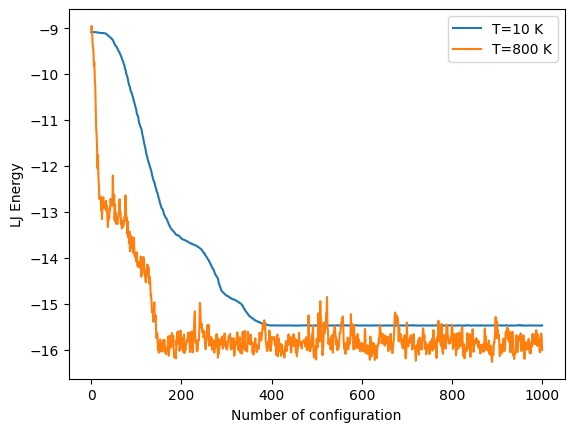

In [ ]:
plt.plot(y3d_10,label='T=10 K')
plt.plot(y3d_800,label='T=800 K')
plt.ylabel('LJ Energy')
plt.xlabel('Number of configuration')
plt.legend()
plt.show()

In [34]:
print(y3d_800[1000],y3d_10[1000])

-16.008836784570516 -15.470095279741427


### MC sampling and dataset for 2D LJ cluster

In [ ]:
# start with original setup
clus2d.set_positions(clus2d_orig_pos)

# set dimensionality
D = 2

# set temperature (in K)
T = 200

# set number of MC steps
mcsteps = 20001

# displacement
sigma = 0.005

# how often to print energy
nprint = 500

# how often to collect data
ncollect = 20

# initialize acceptance counter
nacc = 0
X2d = []
y2d = []

# do a simple MC sampling to create a set of configurations
for i in range(mcsteps):
    
    clus2d, acc = mcstep(clus2d, T, sigma, D, rng)
    
    if acc:
        nacc += 1
    if (i % nprint) == 0:
        print(i,clus2d.get_potential_energy())
        
    if (i % ncollect) == 0:
        dist = clus2d.get_all_distances()
        dist = np.trim_zeros(np.sort(np.ravel(dist)))
        X2d.append(dist[::2])
        y2d.append(clus2d.get_potential_energy())
        
# print acceptances
#print(nacc)
print(f'\nAcceptance ratio: {float(nacc)/float(mcsteps):5.3f}')

X2d_200 = np.array(X2d)
y2d_200 = np.array(y2d)

# print(len(X2d_200))
# print(len(y2d_200))


# T = 2000 K, sigma = 0.02
# T = 200 K, sigma = 0.005

0 -12.419798082657781
500 -12.261664938947849
1000 -12.356459549128546
1500 -12.320976881669113
2000 -12.320766396878438
2500 -12.358239581348355
3000 -12.343986106444888
3500 -12.33452773728152
4000 -12.242232660915533
4500 -12.380022541666328
5000 -12.322214955522158
5500 -12.338463836540909
6000 -12.302258891333262
6500 -12.363172041337265
7000 -12.367439201977046
7500 -12.392497918135726
8000 -12.319745728773636
8500 -12.296272017107084
9000 -12.374599563844313
9500 -12.327833840377187
10000 -12.376032627558953
10500 -12.289395050682273
11000 -12.323036688263198
11500 -12.303543654551943
12000 -12.327547335919649
12500 -12.26012797522402
13000 -12.292210008458689
13500 -12.376110310052773
14000 -12.28520671996576
14500 -12.365906481602446
15000 -12.292265565319536
15500 -12.308354994021343
16000 -12.312765733557836
16500 -12.26704374344879
17000 -12.336863612793705
17500 -12.32634783177864
18000 -12.345517439641153
18500 -12.275794295500546
19000 -12.347960615384693
19500 -12.27927

In [36]:
# start with original setup
clus2d.set_positions(clus2d_orig_pos)

# set dimensionality
D = 2

# set temperature (in K)
T = 2000

# set number of MC steps
mcsteps = 20001

# displacement
sigma = 0.02

# how often to print energy
nprint = 500

# how often to collect data
ncollect = 20

# initialize acceptance counter
nacc = 0
X2d = []
y2d = []

# do a simple MC sampling to create a set of configurations
for i in range(mcsteps):
    
    clus2d, acc = mcstep(clus2d, T, sigma, D, rng)
    
    if acc:
        nacc += 1
    if (i % nprint) == 0:
        print(i,clus2d.get_potential_energy())
        
    if (i % ncollect) == 0:
        dist = clus2d.get_all_distances()
        dist = np.trim_zeros(np.sort(np.ravel(dist)))
        X2d.append(dist[::2])
        y2d.append(clus2d.get_potential_energy())
        
# print acceptances
#print(nacc)
print(f'\nAcceptance ratio: {float(nacc)/float(mcsteps):5.3f}')

X2d_2000 = np.array(X2d)
y2d_2000 = np.array(y2d)

# T = 2000 K, sigma = 0.02
# T = 200 K, sigma = 0.005

0 -12.419798082657781
500 -11.48444786783174
1000 -10.70314776424609
1500 -11.552047591651089
2000 -11.362772915944948
2500 -11.543324032770164
3000 -11.895220098536495
3500 -11.20561570741304
4000 -10.571139491593277
4500 -9.741507198856503
5000 -11.603921871849789
5500 -10.647788936656527
6000 -12.101889682602586
6500 -10.901918818059979
7000 -10.702636582840334
7500 -10.969552498412588
8000 -11.12201661950193
8500 -11.294419160371838
9000 -11.450610052700593
9500 -11.789450906244932
10000 -11.529749914362297
10500 -11.902897392253005
11000 -11.647176280412094
11500 -10.95636793778104
12000 -10.89872115326094
12500 -11.313129089370086
13000 -10.8878607268634
13500 -11.70519365014535
14000 -9.524100902964955
14500 -11.323310654571497
15000 -11.73814377478599
15500 -11.782131676628179
16000 -11.177366305816193
16500 -11.981676609682559
17000 -11.440240359755023
17500 -11.726644129537778
18000 -11.351147578929867
18500 -10.754231384428456
19000 -11.049163444823822
19500 -10.163443218111

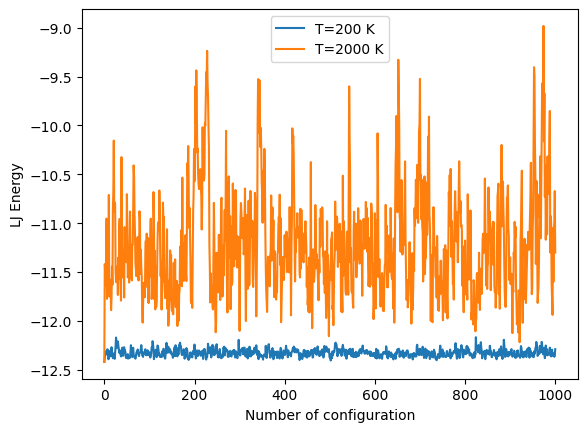

In [37]:
plt.plot(y2d_200,label='T=200 K')
plt.plot(y2d_2000,label='T=2000 K')
plt.ylabel('LJ Energy')
plt.xlabel('Number of configuration')
plt.legend()
plt.show()